In [1]:
# Import Libraries

In [2]:
# Install required libraries
!pip install timm

# Import libraries
import os
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt

from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report


In [3]:
# load the data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ✅ Your exact paths
train_dir = "/content/drive/MyDrive/rice leaf diseasea/train"
test_dir = "/content/drive/MyDrive/rice leaf diseasea/test"

# ✅ Preprocessing (for ViT)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ✅ Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

# ✅ DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# ✅ Check classes
print("Classes:", train_dataset.classes)
print("Number of training images:", len(train_dataset))
print("Number of testing images:", len(test_dataset))


Classes: ['Bacterialblight', 'Brownspot', 'Leafsmut']
Number of training images: 4684
Number of testing images: 208


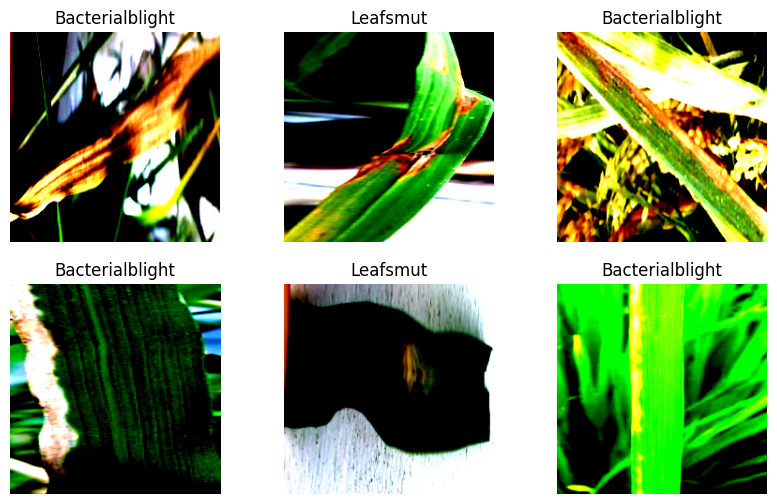

In [6]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i].permute(1,2,0)
    plt.imshow(img)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model('vit_base_patch16_224', pretrained=True)
model.head = nn.Linear(model.head.in_features, 3)  # 3 classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 5
train_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # Evaluate on test set
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {train_losses[-1]:.4f} "
          f"Test Accuracy: {accuracy:.2f}%")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch [1/5] Loss: 0.1774 Test Accuracy: 100.00%
Epoch [2/5] Loss: 0.0500 Test Accuracy: 100.00%
Epoch [3/5] Loss: 0.0003 Test Accuracy: 100.00%
Epoch [4/5] Loss: 0.0000 Test Accuracy: 100.00%
Epoch [5/5] Loss: 0.0000 Test Accuracy: 100.00%


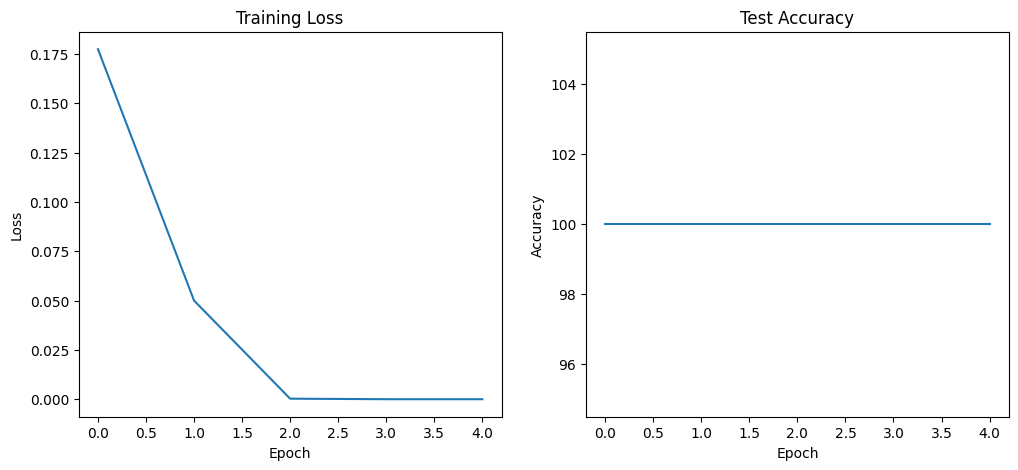

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(test_accuracies)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()


In [9]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))


                 precision    recall  f1-score   support

Bacterialblight       1.00      1.00      1.00        44
      Brownspot       1.00      1.00      1.00       121
       Leafsmut       1.00      1.00      1.00        43

       accuracy                           1.00       208
      macro avg       1.00      1.00      1.00       208
   weighted avg       1.00      1.00      1.00       208



In [10]:
torch.save(model.state_dict(), "vit_leaf_model.pth")
print("Model Saved Successfully!")


Model Saved Successfully!
